# Parkinson's Disease Classifier (46 Penny Features)

Binary classification: **parkinsons** vs **normal**, using the 46 Penny PD-relevant gait features.

## 1. Load extracted features

In [119]:
from ambient.classification.features import GaitFeatureVector
from ambient.utils.features_utils import load_features

FILENAME="extracted_features.pkl"
DIRECTORY="features"

all_features, condition_counts = load_features(filename=FILENAME, directory=DIRECTORY)
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: features/extracted_features.pkl
  Saved on: 2026-01-24T00:29:12.626096
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']

Total features loaded: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples


In [83]:
print(f"# Samples: {len(all_features)}, type: {type(all_features[0])}")

# Samples: 68, type: <class 'ambient.classification.features.GaitFeatureVector'>


In [84]:
import numpy as np
from ambient.classification.features import GaitFeatureVector

# 46 Penny PD-relevant features (excludes joint means, metadata, aggregate symmetry scores, etc.)
PENNY_FEATURES = [
    "hip_asymmetry",
    "ankle_asymmetry",
    "knee_asymmetry",
    "left_hip_range",
    "right_hip_range",
    "left_knee_range",
    "right_knee_range",
    "left_ankle_range",
    "right_ankle_range",
    "stride_length_m",
    "walking_speed_ms",
    "cadence_steps_min",
    "stance_percentage",
    "swing_percentage",
    "double_support_percentage",
    "stance_swing_ratio",
    "stride_length_si",
    "stance_time_si",
    "swing_time_si",
    "hip_angle_si",
    "knee_angle_si",
    "ankle_angle_si",
    "acceleration_std",
    "jerk_mean",
    "jerk_std",
    "stride_time_cv",
    "step_length_cv",
    "stride_velocity_cv",
    "trunk_lean_angle",
    "com_movement_mean",
    "com_movement_std",
    "com_stability_index",
    "postural_sway_area",
    "ankle_distance_asymmetry",
    "shoulder_symmetry_index",
    "elbow_symmetry_index",
    "wrist_symmetry_index",
    "hip_symmetry_index",
    "knee_symmetry_index",
    "ankle_symmetry_index",
    "cycle_count",
    "cycle_duration_asymmetry",
    "double_support_duration_mean",
    "stance_duration_mean",
    "swing_duration_mean",
    "phase_asymmetry",
]

ALL_FEATURE_NAMES = GaitFeatureVector.get_feature_names()
name_to_idx = {name: i for i, name in enumerate(ALL_FEATURE_NAMES)}
missing = [name for name in PENNY_FEATURES if name not in name_to_idx]
if missing:
    raise ValueError(f"Unknown feature names: {missing}")
FEATURE_INDICES = [name_to_idx[name] for name in PENNY_FEATURES]


class PennyFeatureVector:
    """Wrapper so to_array() returns only the 46 Penny features.

    BaseGaitClassifier.train() builds X with f.to_array() directly, while
    evaluate() uses _prepare_features(). Patching only _prepare_features leaves
    the scaler fit on 82 features but applied to 46 at evaluation time.
    """

    def __init__(self, inner: GaitFeatureVector):
        object.__setattr__(self, "_inner", inner)

    def __getattr__(self, name):
        return getattr(self._inner, name)

    def to_array(self, feature_groups=None):
        if feature_groups is not None:
            raise ValueError("PennyFeatureVector always returns the fixed 46-feature subset")
        return self._inner.to_array()[FEATURE_INDICES]

    @classmethod
    def get_feature_names(cls):
        return list(PENNY_FEATURES)


def subset_features(features):
    return [PennyFeatureVector(f) for f in features]


def configure_penny_classifier(classifier):
    classifier.feature_names = list(PENNY_FEATURES)


print(f"Using {len(PENNY_FEATURES)} of {len(ALL_FEATURE_NAMES)} extracted features")

Using 46 of 82 extracted features


## 2. Splitting Training vs Testing datasets

In [85]:
import numpy as np

In [86]:
def get_train_test(all_features: list, train_portion: float = 0.8):
    np.random.seed(42)

    by_condition = {}
    for i, feature in enumerate(all_features):
        by_condition.setdefault(feature.condition_label, []).append(i)

    train_indices = []
    test_indices = []
    for indices in by_condition.values():
        indices = np.array(indices)
        np.random.shuffle(indices)
        split_idx = int(train_portion * len(indices))
        train_indices.extend(indices[:split_idx].tolist())
        test_indices.extend(indices[split_idx:].tolist())

    train_features = [all_features[i] for i in train_indices]
    test_features = [all_features[i] for i in test_indices]

    return train_features, test_features

In [87]:
PD_CONDITIONS = {"parkinsons", "normal"}

all_features = [
    f for f in all_features
    if f is not None and f.condition_label in PD_CONDITIONS
]

from collections import Counter

print("Samples after filtering to Parkinson's vs normal:")
for condition, count in sorted(Counter(f.condition_label for f in all_features).items()):
    print(f"  {condition:15s}: {count:3d} samples")

Samples after filtering to Parkinson's vs normal:
  normal         :  12 samples
  parkinsons     :   9 samples


In [88]:
train_features, test_features = get_train_test(all_features, 0.7)
train_features = subset_features(train_features)
test_features = subset_features(test_features)

len(train_features), len(test_features), len(all_features)

(14, 7, 21)

## 3. Classification with KNN

In [89]:
from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig
)

In [90]:
config = KNNClassifierConfig(
    n_neighbors=3,
    weights="distance",
    metric="euclidean",
    normalize_features=True
)

In [91]:
knn_classifier = KNNGaitClassifier(config=config)
configure_penny_classifier(knn_classifier)

2026-06-14 14:35:33.781 | INFO     | ambient.classification.knn_classifier:__init__:87 - KNN classifier initialized with k=3


### Training

In [92]:
knn_metrics = knn_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

2026-06-14 14:35:33.786 | INFO     | ambient.classification.base_classifier:train:153 - Training KNNGaitClassifier with 14 samples
2026-06-14 14:35:33.786 | INFO     | ambient.classification.base_classifier:train:154 - Feature shape: (14, 46)
2026-06-14 14:35:33.787 | INFO     | ambient.classification.base_classifier:train:155 - Classes: ['normal' 'parkinsons']
2026-06-14 14:35:33.790 | INFO     | ambient.classification.base_classifier:train:237 - Class distribution: {np.str_('normal'): np.int64(8), np.str_('parkinsons'): np.int64(6)}
2026-06-14 14:35:33.791 | INFO     | ambient.classification.base_classifier:train:242 - Features normalized using StandardScaler
2026-06-14 14:35:33.801 | INFO     | ambient.classification.base_classifier:train:308 - Cross-validation accuracy: 0.767 ± 0.200
2026-06-14 14:35:33.801 | INFO     | ambient.classification.base_classifier:train:312 - Training complete. Accuracy: 1.000


### Evaluation

In [93]:
eval_metrics = knn_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:33.814 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 1.000
2026-06-14 14:35:33.815 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 1.000


Eval accuracy: 1.0


In [94]:
eval_metrics = knn_classifier.evaluate(test_features=test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:33.826 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 0.714
2026-06-14 14:35:33.827 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 0.708


Eval accuracy: 0.7142857142857143


In [95]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


normal
  F1-Score : 0.750
  Precision: 0.750
  Recall   : 0.750

parkinsons
  F1-Score : 0.667
  Precision: 0.667
  Recall   : 0.667


### Evaluation Confusion Matrix

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

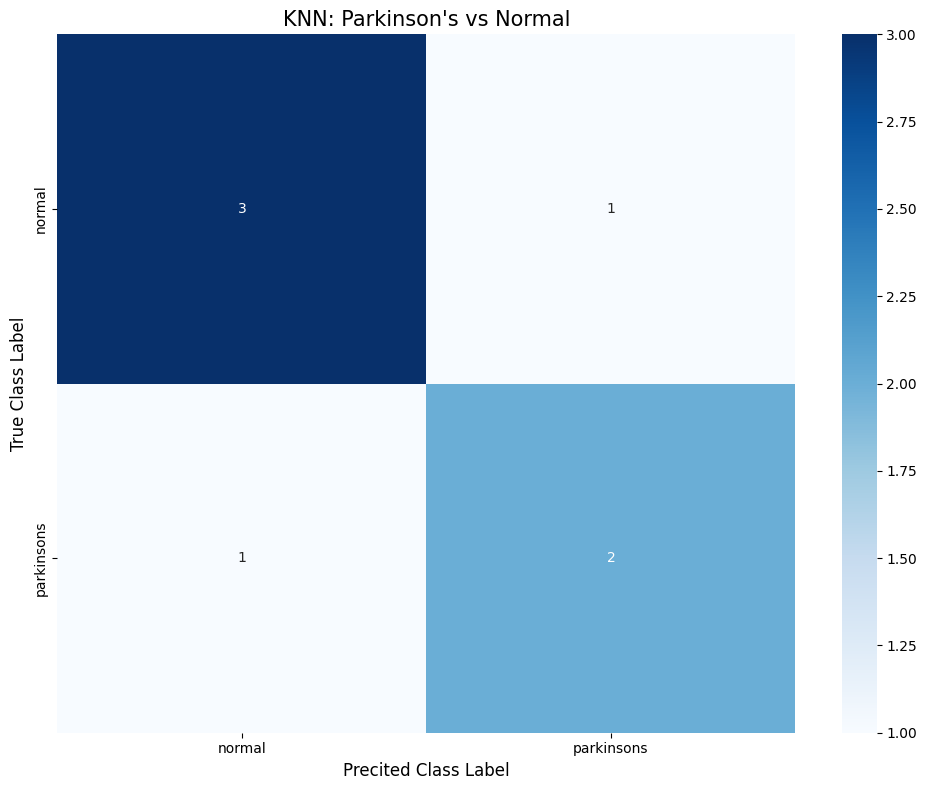

In [97]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title("KNN: Parkinson's vs Normal", fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Classification with Decision Tree

In [98]:
from ambient.classification.decisiontree_classifier import(
    DecisionTreeGaitClassifier,
    DecisionTreeClassifierConfig
)

In [99]:
dt_config = DecisionTreeClassifierConfig(
    criterion='gini',
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    class_weight='balanced',
    normalize_features=True,
    random_state=42
)

dt_classifier = DecisionTreeGaitClassifier(dt_config)
configure_penny_classifier(dt_classifier)

2026-06-14 14:35:34.013 | INFO     | ambient.classification.decisiontree_classifier:__init__:84 - Decision Tree classifier initialized with gini criterion


### Training

In [100]:
dt_metrics = dt_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

print(f"training accuracy: {dt_metrics['train_accuracy']}")

2026-06-14 14:35:34.019 | INFO     | ambient.classification.base_classifier:train:153 - Training DecisionTreeGaitClassifier with 14 samples
2026-06-14 14:35:34.019 | INFO     | ambient.classification.base_classifier:train:154 - Feature shape: (14, 46)
2026-06-14 14:35:34.020 | INFO     | ambient.classification.base_classifier:train:155 - Classes: ['normal' 'parkinsons']
2026-06-14 14:35:34.020 | INFO     | ambient.classification.base_classifier:train:237 - Class distribution: {np.str_('normal'): np.int64(8), np.str_('parkinsons'): np.int64(6)}
2026-06-14 14:35:34.021 | INFO     | ambient.classification.base_classifier:train:242 - Features normalized using StandardScaler
2026-06-14 14:35:34.031 | INFO     | ambient.classification.base_classifier:train:308 - Cross-validation accuracy: 0.733 ± 0.327
2026-06-14 14:35:34.031 | INFO     | ambient.classification.base_classifier:train:312 - Training complete. Accuracy: 0.929
2026-06-14 14:35:34.031 | INFO     | ambient.classification.decisiont

training accuracy: 0.9285714285714286


### Evaluation

In [101]:
eval_metrics = dt_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:34.044 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 0.929
2026-06-14 14:35:34.045 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 0.928


Eval accuracy: 0.9285714285714286


In [102]:
eval_metrics = dt_classifier.evaluate(test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:34.055 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 0.857
2026-06-14 14:35:34.055 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 0.857


Eval accuracy: 0.8571428571428571


In [103]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


normal
  F1-Score : 0.857
  Precision: 1.000
  Recall   : 0.750

parkinsons
  F1-Score : 0.857
  Precision: 0.750
  Recall   : 1.000


### Evaluation Confusion Matrix

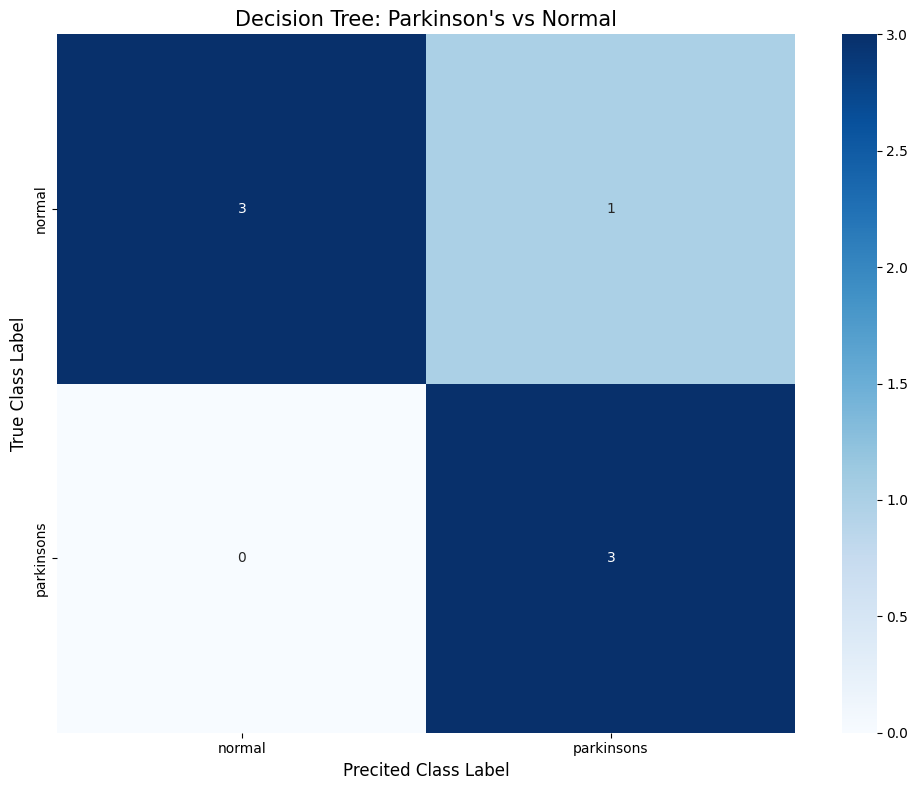

In [104]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title("Decision Tree: Parkinson's vs Normal", fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()

### Visualize Decision Tree

In [105]:
if 'feature_importances' in dt_metrics:
    print("Top 5 Most Important Features:")
    for feat in dt_metrics['feature_importances'][:5]:
        print(f"    {feat['rank']}. {feat['feature']:20s}: {feat['importance']:.3f}")

Top 5 Most Important Features:
    1. step_length_cv      : 0.907
    2. wrist_symmetry_index: 0.093
    3. hip_asymmetry       : 0.000
    4. ankle_asymmetry     : 0.000
    5. knee_asymmetry      : 0.000


Using 46 Penny features for tree visualization


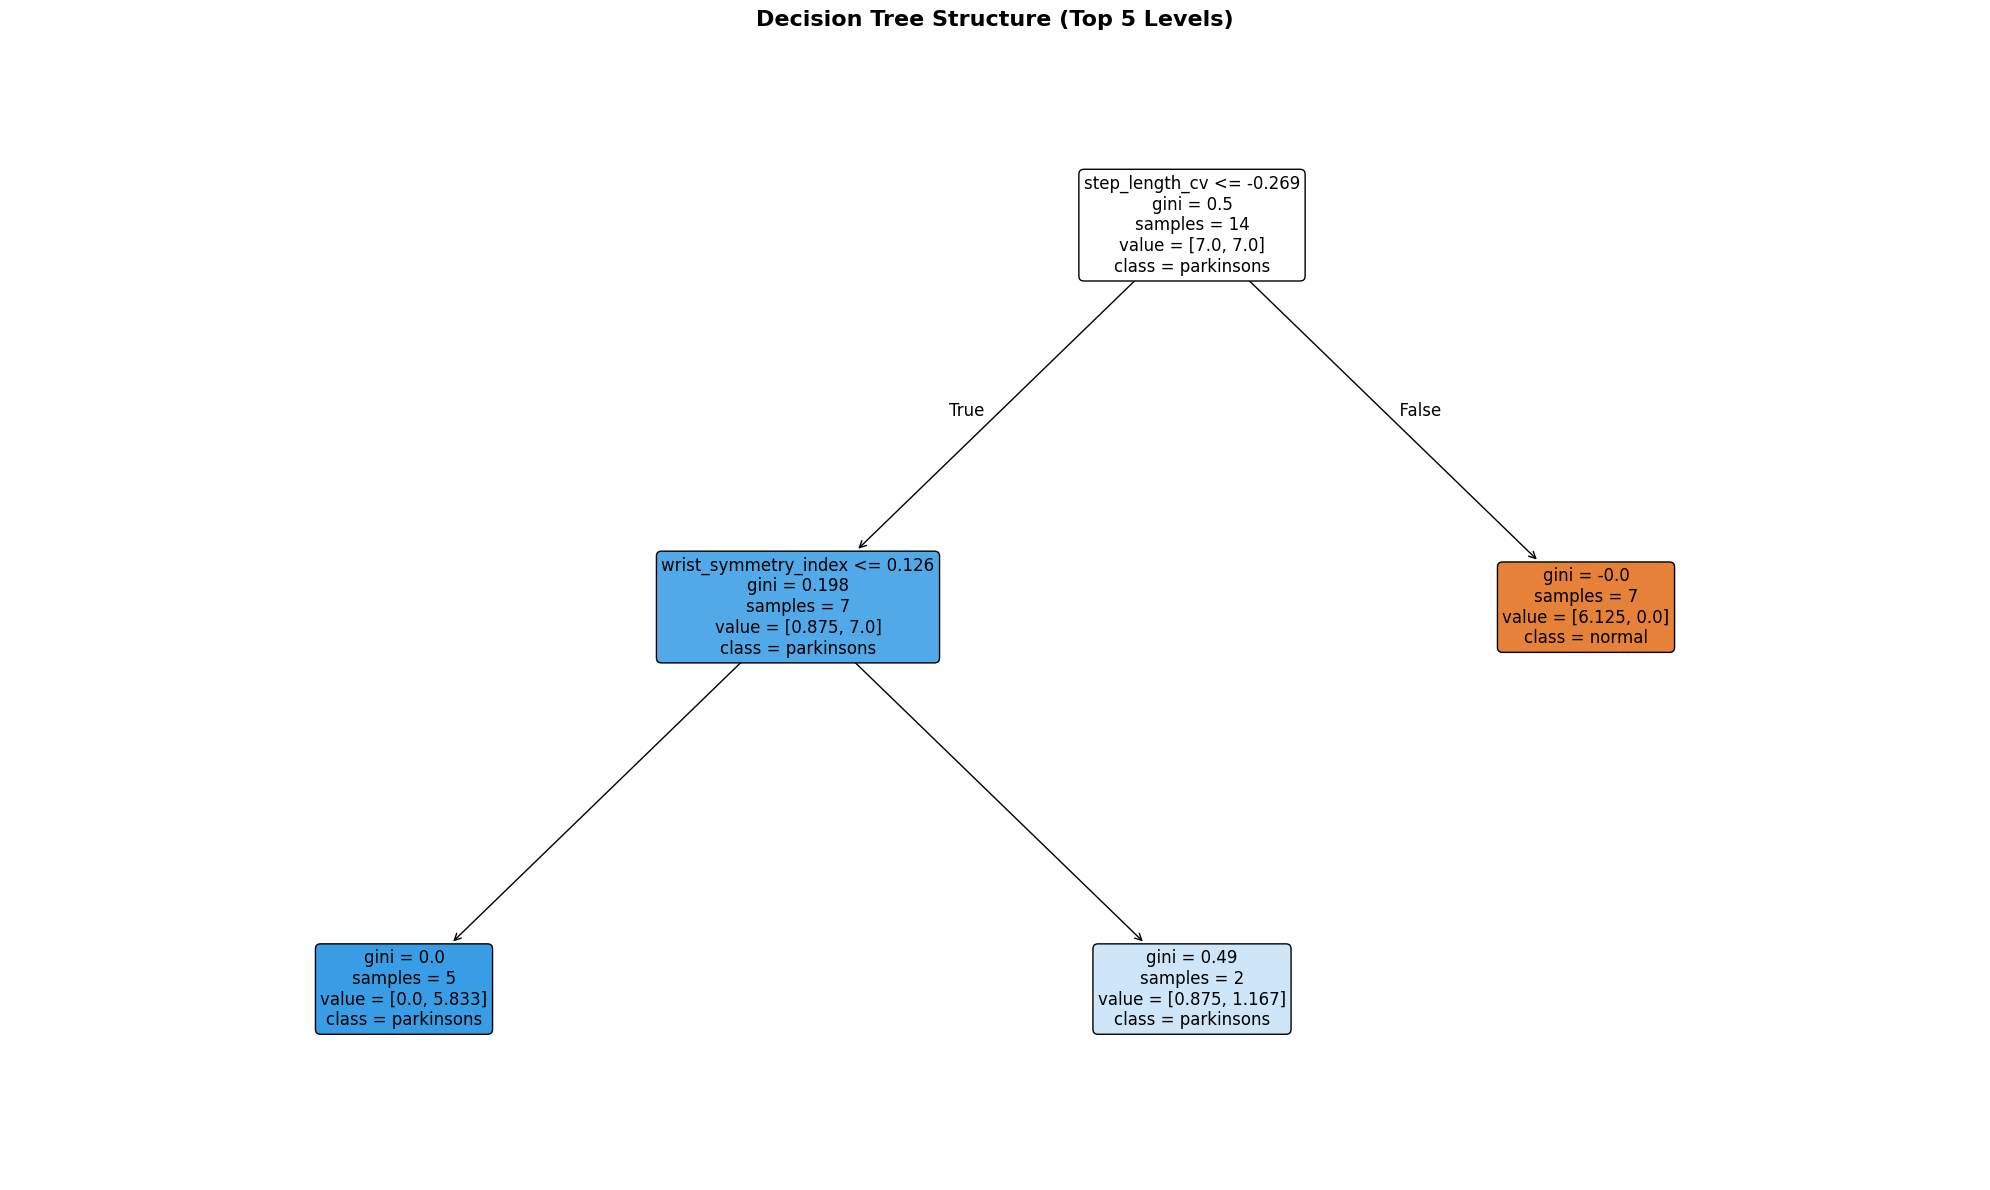

In [106]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the underlying sklearn model
sklearn_model = dt_classifier.model

feature_names = dt_classifier.feature_names
print(f"Using {len(feature_names)} Penny features for tree visualization")

# Get class names
class_names = eval_metrics['classes']

### 5.1 Visual Tree Plot
plt.figure(figsize=(20, 12))
plot_tree(sklearn_model, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=5,  # Limit depth for readability
)
plt.title('Decision Tree Structure (Top 5 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Classification with Random Forest

In [107]:
from ambient.classification.rf_classifier import (
    RFClassifierConfig,
    RFGaitClassifier
)

In [108]:
rf_config = RFClassifierConfig(
    n_estimators = 100,
    max_depth = 5,
)

rf_classifier = RFGaitClassifier(rf_config)
configure_penny_classifier(rf_classifier)

2026-06-14 14:35:34.228 | INFO     | ambient.classification.rf_classifier:__init__:116 - Random Forest classifier initialized with 100 trees


### Training

In [109]:
rf_metrics = rf_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

print(f"training accuracy: {rf_metrics['train_accuracy']}")

2026-06-14 14:35:34.233 | INFO     | ambient.classification.base_classifier:train:153 - Training RFGaitClassifier with 14 samples
2026-06-14 14:35:34.233 | INFO     | ambient.classification.base_classifier:train:154 - Feature shape: (14, 46)
2026-06-14 14:35:34.234 | INFO     | ambient.classification.base_classifier:train:155 - Classes: ['normal' 'parkinsons']
2026-06-14 14:35:34.234 | INFO     | ambient.classification.base_classifier:train:237 - Class distribution: {np.str_('normal'): np.int64(8), np.str_('parkinsons'): np.int64(6)}
2026-06-14 14:35:34.235 | INFO     | ambient.classification.base_classifier:train:242 - Features normalized using StandardScaler
2026-06-14 14:35:34.655 | INFO     | ambient.classification.base_classifier:train:308 - Cross-validation accuracy: 0.733 ± 0.327
2026-06-14 14:35:34.655 | INFO     | ambient.classification.base_classifier:train:312 - Training complete. Accuracy: 1.000
2026-06-14 14:35:34.682 | INFO     | ambient.classification.rf_classifier:train

training accuracy: 1.0


### Evaluation

In [110]:
eval_metrics = rf_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:34.707 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 1.000
2026-06-14 14:35:34.707 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 1.000


Eval accuracy: 1.0


In [111]:
eval_metrics = rf_classifier.evaluate(test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-06-14 14:35:34.732 | INFO     | ambient.classification.base_classifier:evaluate:426 - Test accuracy: 1.000
2026-06-14 14:35:34.732 | INFO     | ambient.classification.base_classifier:evaluate:427 - Test F1 score: 1.000


Eval accuracy: 1.0


In [112]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


normal
  F1-Score : 1.000
  Precision: 1.000
  Recall   : 1.000

parkinsons
  F1-Score : 1.000
  Precision: 1.000
  Recall   : 1.000


### Evaluation Confusion Matrix

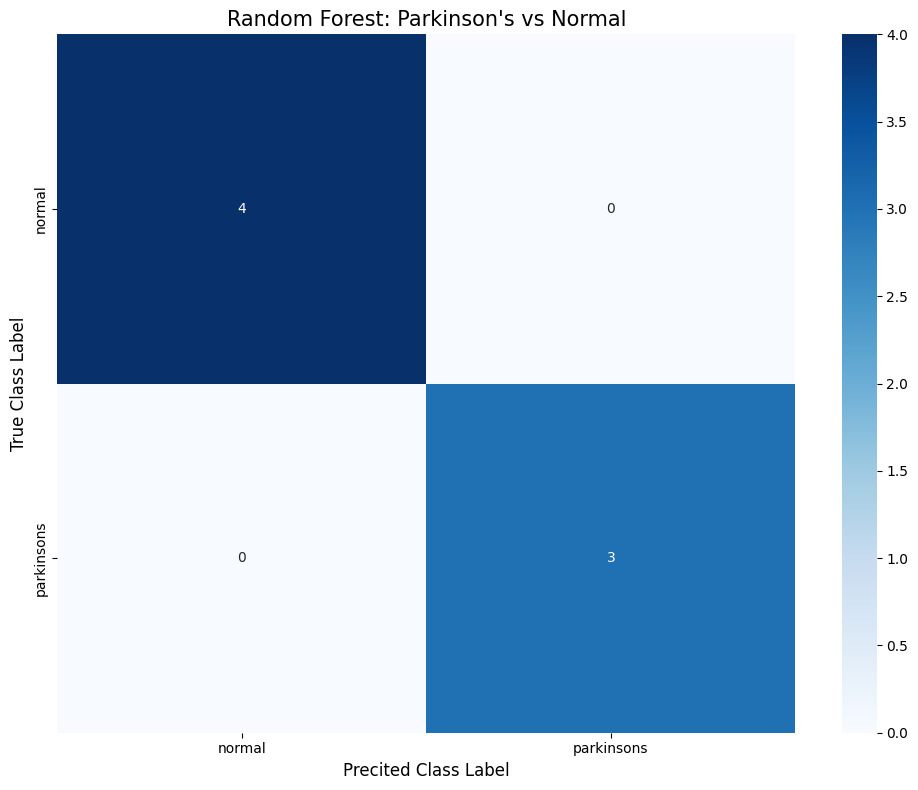

In [113]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title("Random Forest: Parkinson's vs Normal", fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()